# MedAESQA EDA — FaithfulMed (Google 2D)

Owner: Isha | September milestone, Task #1

**What this notebook is for.** MedAESQA is our evaluation backbone, not training data.
So this EDA is scoped to three consumers:

1. **Verifier owner** — human label distributions, class balance, and the good-to-bad
   quality spread across M1–M30. Needed for Cohen's kappa calibration in October.
2. **Extractor owner** — the structure of `expert_curated_nuggets`, which is our gold
   schema for clinical atoms.
3. **Everyone** — how far the source text sits from an 8th-grade reading level.

**Output of this notebook:** a flat sentence-level CSV (`medaesqa_sentences.csv`) plus a
question-level CSV. Those are the artifacts the rest of the team actually consumes.

> Nested field names inside `question_frame`, `expert_curated_answer`, etc. are confirmed
> in Section 1 against the real file. Check them against the OSF README and fix the
> accessor helpers if they differ.

## 0. Setup

In [ ]:
!pip install -q textstat pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 40.8 MB/s eta 0:00:00


In [ ]:
import json, collections, statistics, re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textstat

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

# Download medaesqa_v1.json from https://osf.io/ydbzq/ and put it here.
DATA_PATH = Path("medaesqa_v1.json")

with open(DATA_PATH) as f:
    raw = json.load(f)

# The file may be a list of items or a dict keyed by question_id. Normalize to a list.
items = raw if isinstance(raw, list) else list(raw.values())
print(f"{len(items)} top-level items (expect 40)")

40 top-level items (expect 40)


## 1. Schema inventory

Do not skip this. Print the real structure before writing any analysis code, and update
the accessors below to match. Everything downstream depends on getting this right once.

In [ ]:
def describe(node, path="", depth=0, max_depth=4, seen=None):
    """Recursively print the shape of a nested JSON structure."""
    if seen is None:
        seen = set()
    pad = "  " * depth
    if depth > max_depth:
        print(f"{pad}...")
        return
    if isinstance(node, dict):
        entries = list(node.items())
        # 30 near-identical M1..M30 blocks bury everything else, so show a couple.
        if len(entries) > 4 and all(re.fullmatch(r"M\d+", k) for k, _ in entries):
            print(f"{pad}({len(entries)} methods: {entries[0][0]}..{entries[-1][0]}, showing 2)")
            entries = entries[:2]
        for k, v in entries:
            key_path = f"{path}.{k}" if path else k
            if isinstance(v, (dict, list)):
                kind = type(v).__name__
                size = f"[{len(v)}]" if isinstance(v, list) else ""
                print(f"{pad}{k}: {kind}{size}")
                if key_path not in seen:
                    seen.add(key_path)
                    describe(v, key_path, depth + 1, max_depth, seen)
            else:
                preview = str(v)[:70].replace("\n", " ")
                print(f"{pad}{k}: {type(v).__name__} = {preview!r}")
    elif isinstance(node, list) and node:
        describe(node[0], f"{path}[0]", depth, max_depth, seen)


describe(items[0])

question_id: str = '116'
question: str = 'Are there ways to prevent sleep apnea or treat it naturally?'
question_frame: dict
  Focus: str = 'sleep apnea'
  Type: str = 'Treatment'
  Task: str = 'Decision support'
  Subject matter (focus): str = 'clinical / problem'
  Body system: str = 'respiratory'
  Specialty: str = 'pulmonology/ ENT / cardiology'
expert_curated_answer: str = ' There are ways to prevent and treat sleep apnea naturally. Lifestyle '
machine_generated_answers: dict
  (30 methods: M1..M30, showing 2)
  M1: dict
    answer: str = 'There are several natural ways to prevent and treat sleep apnea [22014'
    is_answer_accurate: str = 'yes'
    answer_sentences: list[6]
      answer_sentence_id: str = '1'
      answer_sentence: str = 'There are several natural ways to prevent and treat sleep apnea [22014'
      answer_sentence_relevance: str = 'required'
      citation_assessment: list[1]
        cited_pmid: str = '22014867'
        evidence_support: str = 'Dietary modificati

In [ ]:
# Which top-level keys appear on every item, and which are sometimes missing?
key_counts = collections.Counter(k for it in items for k in it.keys())
pd.Series(key_counts).sort_values(ascending=False).to_frame("n_items")

,n_items
question_id,40
question,40
question_frame,40
expert_curated_answer,40
machine_generated_answers,40
nuggets,40


### 1b. Accessor helpers

These are deliberately tolerant of naming variation. Once you have confirmed the real
field names from Section 1, replace the candidate lists with the exact keys and delete
the fallbacks. Silent fallbacks are fine for exploration and dangerous in a frozen
eval set.

In [ ]:
def first_key(d, *candidates, default=None):
    """Return the first present key from candidates, else default."""
    if not isinstance(d, dict):
        return default
    for c in candidates:
        if c in d:
            return d[c]
    return default


def as_text(node):
    """Coerce an answer field to a plain string."""
    if node is None:
        return ""
    if isinstance(node, str):
        return node
    if isinstance(node, dict):
        direct = first_key(node, "text", "answer", "answer_text")
        if direct is not None:
            return as_text(direct)
        for k in ("sentences", "answer_sentences", "statements", "assertions"):
            if isinstance(node.get(k), list):
                return as_text(node[k])
        return ""
    if isinstance(node, list):
        parts = []
        for x in node:
            if isinstance(x, str):
                parts.append(x)
            elif isinstance(x, dict):
                parts.append(as_text(first_key(x, "sentence", "text", "answer_sentence", default="")))
        return " ".join(p for p in parts if p)
    return str(node)


def sentences_of(answer_node):
    """Return the list of per-sentence dicts for an answer, if the file stores them."""
    if isinstance(answer_node, dict):
        for k in ("sentences", "answer_sentences", "statements", "assertions"):
            if k in answer_node and isinstance(answer_node[k], list):
                return answer_node[k]
    if isinstance(answer_node, list):
        return answer_node
    return []


def norm_label(x):
    return str(x).strip().lower() if x is not None else None


# The file uses present participles ("supporting") where the paper uses
# base forms ("supports"). Normalize so our labels match the published tables.
RELATION_MAP = {
    "supporting": "supports",
    "supports": "supports",
    "contradicting": "contradicts",
    "contradicts": "contradicts",
    "neutral": "neutral",
    "not relevant": "not_relevant",
    "not_relevant": "not_relevant",
    "irrelevant": "not_relevant",
}


def norm_relation(x):
    lab = norm_label(x)
    return RELATION_MAP.get(lab, lab)


PMID_RE = re.compile(r"\[([\d,;\s]+)\]")


def pmids_in_text(text):
    # Pull bracketed PMIDs out of an answer string, e.g. "... [22014867]."
    out = []
    for group in PMID_RE.findall(text or ""):
        out.extend(re.findall(r"\d{5,9}", group))
    return out

## 2. Question-level view

40 questions, drawn from the most popular previously-unseen questions submitted by
self-identified non-clinicians to MedlinePlus. Each carries expert-coded `topic` and
`narrative`, plus a `question_frame` with question focus, question type, Subject Matter,
Body System, and Specialty.

Why this matters for us: our pipeline has to handle whatever mix of specialties and
answer types is in here. If the gold set is 70% one body system, that is a limitation
worth naming in the December report.

In [ ]:
q_rows = []
for it in items:
    frame = first_key(it, "question_frame", default={}) or {}
    q_rows.append({
        "question_id": first_key(it, "question_id", "qid"),
        "question": first_key(it, "question", default=""),
        "question_focus": first_key(frame, "Focus"),
        "question_type": first_key(frame, "Type"),
        "task": first_key(frame, "Task"),
        "subject_matter": first_key(frame, "Subject matter (focus)"),
        "body_system": first_key(frame, "Body system"),
        "specialty": first_key(frame, "Specialty"),
    })

questions = pd.DataFrame(q_rows)
questions["q_words"] = questions["question"].str.split().str.len()
questions.head()

,question_id,question,question_focus,question_type,task,subject_matter,body_system,specialty,q_words
0,116,Are there ways to prevent sleep apnea or treat it naturally?,sleep apnea,Treatment,Decision support,clinical / problem,respiratory,pulmonology/ ENT / cardiology,11
1,117,What will mutation in runx2 affect in the future?,runx2 mutation,Manifestation,Effect,genetics,full body,clinical genetics,9
2,118,how long does a minor cornea injury take to heal without medical attention?,corneal abrasion,Prognosis,Factoid,clinical / problem,visual,ophthalmology,13
3,119,what drug or combination of drugs is most popular for treating stage 4 copd?,COPD,Treatment,Decision support,clinical / problem,respiratory,pulmonology,14
4,120,what causes left sided facial numbness?,facial numbness,Etiology,Factoid,clinical / problem,nervous,neurology,6


       q_words
count     40.0
mean       9.4
std        3.9
min        4.0
25%        6.8
50%        8.5
75%       12.0
max       21.0


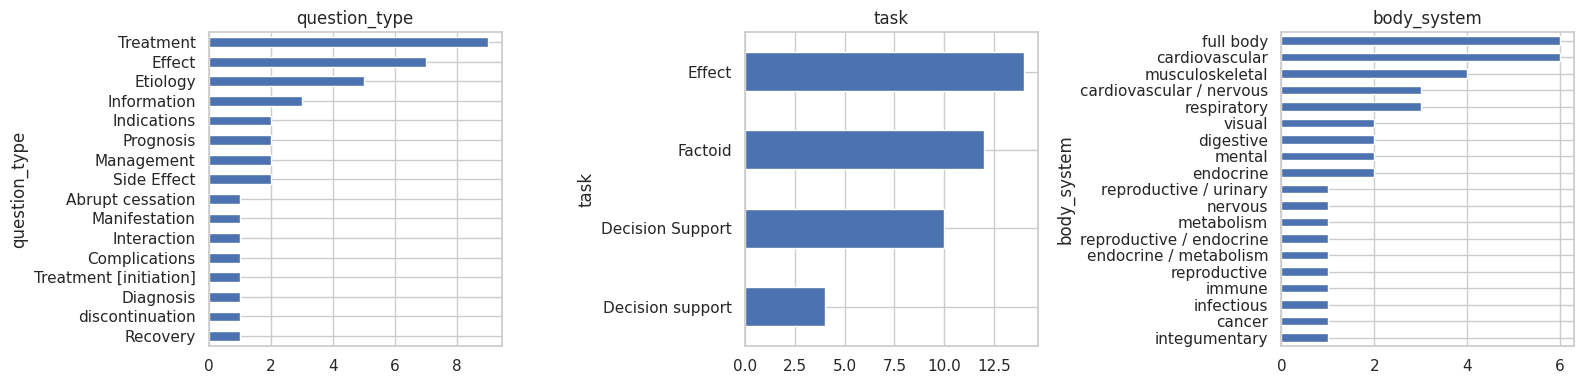

,count
specialty,
clinical genetics,4
cardiology,4
neurology,3
endocrinology,3
GP/ cardiology,3
pulmonology,2
ophthalmology,2
psychiatry,2
hepatology,2


In [ ]:
print(questions[["q_words"]].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["question_type", "task", "body_system"]):
    vc = questions[col].fillna("(missing)").value_counts()
    vc.plot(kind="barh", ax=ax)
    ax.set_title(col)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

questions["specialty"].fillna("(missing)").value_counts()

## 3. Expert-curated answers

The expert answer is our ceiling for faithfulness and our floor for readability. Each
sentence carries PMIDs supporting its assertions, and the expert answers contain 316
references total, between 3 and 10 per answer.

**The headline number to pull out of this section:** the Flesch-Kincaid grade level of the
expert answers. Our success criterion is 80% of outputs at grade 8 or below. Showing how
far above that the source sits is the motivating stat for the whole project.

In [ ]:
def fk_metrics(text):
    if not text or len(text.split()) < 5:
        return {"fk_grade": np.nan, "smog": np.nan, "n_words": len(text.split())}
    return {
        "fk_grade": textstat.flesch_kincaid_grade(text),
        "smog": textstat.smog_index(text),
        "n_words": len(text.split()),
    }


exp_rows = []
for it in items:
    ans = first_key(it, "expert_curated_answer", "expert_answer", default=None)
    text = as_text(ans)
    sents = sentences_of(ans)
    row = {
        "question_id": first_key(it, "question_id", "qid"),
        "n_sentences": len(sents) if sents else text.count(". ") + 1,
        "text": text,
    }
    row.update(fk_metrics(text))
    exp_rows.append(row)

expert = pd.DataFrame(exp_rows)
print(expert[["fk_grade", "smog", "n_words", "n_sentences"]].describe().round(2))

pct_at_target = (expert["fk_grade"] <= 8).mean() * 100
print(f"\nExpert answers already at <= grade 8: {pct_at_target:.1f}%")

       fk_grade   smog  n_words  n_sentences
count     40.00  40.00     40.0        40.00
mean      11.79  13.32     92.5         4.85
std        2.72   2.38     36.7         1.97
min        6.31   8.84     45.0         2.00
25%        9.96  12.09     66.0         3.00
50%       11.53  13.02     88.0         4.00
75%       13.25  14.12    101.0         6.00
max       19.79  19.78    204.0        10.00

Expert answers already at <= grade 8: 7.5%


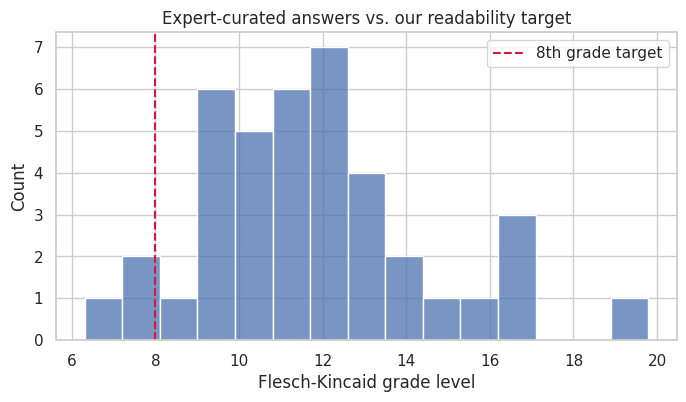

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(expert["fk_grade"].dropna(), bins=15, ax=ax)
ax.axvline(8, color="crimson", ls="--", label="8th grade target")
ax.set_xlabel("Flesch-Kincaid grade level")
ax.set_title("Expert-curated answers vs. our readability target")
ax.legend()
plt.show()

In [ ]:
# expert_curated_answer is a plain string with PMIDs in square brackets,
# so references come out with a regex rather than a key lookup.
# Paper reports 316 total, min 3 and max 10 per answer.
expert["n_refs"] = expert["text"].map(lambda t: len(set(pmids_in_text(t))))
print(expert["n_refs"].describe().round(1))
print("total unique-per-answer refs:", expert["n_refs"].sum(), "(paper: 316)")

count    40.0
mean      8.0
std       1.7
min       3.0
25%       7.0
50%       8.0
75%       9.0
max      10.0
Name: n_refs, dtype: float64
total unique-per-answer refs: 320 (paper: 316)


## 4. Expert nuggets — the Extractor's gold schema

Nuggets are atomic facts in `Predicate(subject, object)` form, e.g. `Treat(treatment,
condition)` or `Prevent(method, condition)`, with each medical concept mapped to a UMLS
CUI. Exactly one nugget was generated per fact in each expert answer, and each was
reviewed by at least two people. Some use more complex structures like if/then clauses
and comparisons.

**What to hand the Extractor owner:** the predicate vocabulary, how many nuggets per
question, CUI coverage, and the share that break the simple two-argument pattern. That
last one tells them how much schema complexity they actually need.

In [ ]:
# Look at one raw nugget before parsing, so the field names below are grounded.
print(json.dumps(first_key(items[0], "nuggets", "expert_curated_nuggets", default=[])[:3],
                 indent=2)[:1500])

[
  "Exists (treat naturally[C0027495], sleep apnea [C0037315])",
  "[may] Prevent (lifestyle changes [C0870811], sleep apnea [C0037315])",
  "[may] Treat (lifestyle changes [C0870811], sleep apnea [C0037315])"
]


In [ ]:
nug_rows = []
for it in items:
    qid = first_key(it, "question_id", "qid")
    nuggets = first_key(it, "expert_curated_nuggets", "nuggets", default=[]) or []
    for n in nuggets:
        if isinstance(n, str):
            body, cuis = n, []
        else:
            body = as_text(first_key(n, "nugget", "text", "predicate", default=""))
            cuis = first_key(n, "cuis", "CUI", "cui", default=[]) or []
            if isinstance(cuis, str):
                cuis = [cuis]
        m = re.match(r"\s*([A-Za-z_ ]+?)\s*\((.*)\)\s*$", body)
        nug_rows.append({
            "question_id": qid,
            "nugget": body,
            "predicate": m.group(1).strip() if m else None,
            "args_raw": m.group(2) if m else None,
            "n_args": len(m.group(2).split(",")) if m else None,
            "n_cuis": len(cuis),
        })

nuggets_df = pd.DataFrame(nug_rows)
print(f"{len(nuggets_df)} nuggets across {nuggets_df['question_id'].nunique()} questions")
print(nuggets_df.groupby("question_id").size().describe().round(1))

nuggets_df["predicate"].value_counts().head(25)

498 nuggets across 40 questions
count    40.0
mean     12.4
std       5.5
min       3.0
25%       9.0
50%      11.5
75%      16.0
max      31.0
dtype: float64


,count
predicate,
Is,55
Associated,27
Cause,27
Include,25
Treat,25
Reduce,17
Help,11
Symptom,10
increased risk,10


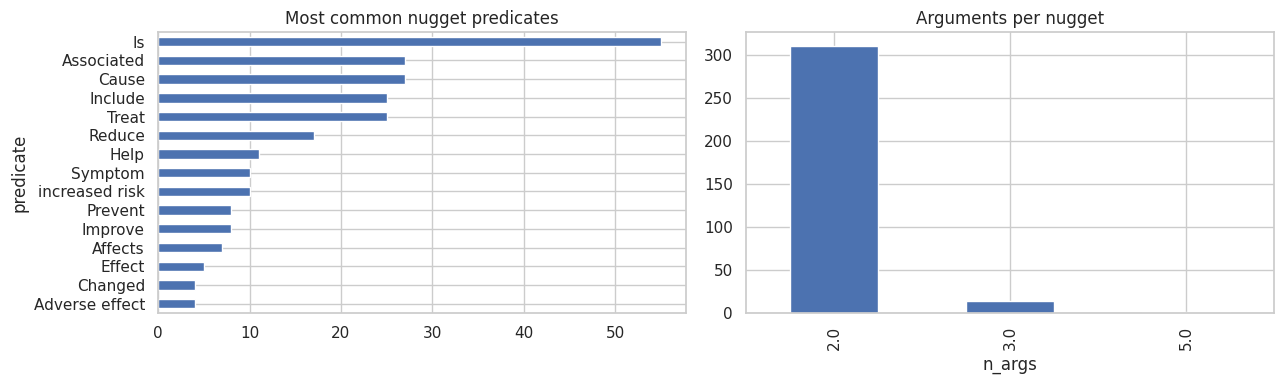

Nuggets that don't fit Predicate(a, b): 34.5%  <- schema complexity the Extractor must handle
Nuggets with at least one CUI: 0.0%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
nuggets_df["predicate"].value_counts().head(15).plot(kind="barh", ax=axes[0])
axes[0].set_title("Most common nugget predicates")
axes[0].invert_yaxis()
nuggets_df["n_args"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Arguments per nugget")
plt.tight_layout()
plt.show()

unparsed = nuggets_df["predicate"].isna().mean() * 100
print(f"Nuggets that don't fit Predicate(a, b): {unparsed:.1f}%  <- schema complexity the Extractor must handle")
print(f"Nuggets with at least one CUI: {(nuggets_df['n_cuis'] > 0).mean() * 100:.1f}%")

## 5. Machine answers and human labels — the Verifier's calibration set

This is the most important section for October. 30 answers per question, 1,240 answers
total, 5,162 answer sentences. Two label axes:

- **Sentence relevance:** required / unnecessary / borderline / inappropriate
- **Evidence relation** (per citation): supports / contradicts / neutral / not relevant

Known totals from the paper, useful as a sanity check on your parsing: 1,108 of 1,200
machine answers judged acceptable, 3,958 of 5,162 sentences judged required, 5,489 of
8,111 references judged supporting, and 7,651 human-written evidence excerpts.

If your numbers are way off those, your accessors are wrong. Go back to Section 1.

In [ ]:
sent_rows = []
for it in items:
    qid = first_key(it, "question_id")
    machine = first_key(it, "machine_generated_answers", default={}) or {}

    for method_id, ans in machine.items():
        acceptable = norm_label(first_key(ans, "is_answer_accurate"))

        for si, s in enumerate(first_key(ans, "answer_sentences", default=[]) or []):
            text = first_key(s, "answer_sentence", default="") or ""
            relevance = norm_label(first_key(s, "answer_sentence_relevance"))
            # citation_assessment is either a list or an explicit null
            cites = first_key(s, "citation_assessment") or []

            if not cites:
                cites = [{}]
            for c in cites:
                c = c if isinstance(c, dict) else {}
                sent_rows.append({
                    "question_id": qid,
                    "method_id": method_id,
                    "sentence_id": first_key(s, "answer_sentence_id"),
                    "sentence_idx": si,
                    "sentence": text,
                    "relevance": relevance,
                    "answer_acceptable": acceptable,
                    "pmid": first_key(c, "cited_pmid"),
                    "evidence_relation": norm_relation(first_key(c, "evidence_relation")),
                    "evidence_excerpt": first_key(c, "evidence_support", default="") or "",
                })

sentences = pd.DataFrame(sent_rows)

uniq_sents = sentences.drop_duplicates(["question_id", "method_id", "sentence_idx"])

checks = {
    "unique sentences": (uniq_sents.shape[0], 5162),
    "citation rows": (int(sentences["pmid"].notna().sum()), 8111),
    "evidence excerpts": (int((sentences["evidence_excerpt"].str.len() > 0).sum()), 7651),
}
for name, (got, expected) in checks.items():
    flag = "OK" if abs(got - expected) / expected < 0.05 else "CHECK ACCESSORS"
    print(f"{name:20s} got {got:6d}  paper {expected:6d}   {flag}")

sentences.head()

unique sentences     got   5162  paper   5162   OK
citation rows        got   9611  paper   8111   CHECK ACCESSORS
evidence excerpts    got   7651  paper   7651   OK


,question_id,method_id,sentence_id,sentence_idx,sentence,relevance,answer_acceptable,pmid,evidence_relation,evidence_excerpt
0,116,M1,1,0,There are several natural ways to prevent and treat sleep apnea [22014867].,required,yes,22014867,supports,Dietary modifications may be an effective tool to improve the management of OSAS.
1,116,M1,2,1,"Lifestyle modifications such as weight loss, avoiding alcohol and sedatives, and sleeping on one's side can help all...",required,yes,28126502,supports,Avoiding the supine position during sleep and reducing the overnight rostral fluid shift from the legs to the neck c...
2,116,M1,2,1,"Lifestyle modifications such as weight loss, avoiding alcohol and sedatives, and sleeping on one's side can help all...",required,yes,28126502,supports,Weight-loss intervention is a central component of the strategies used to improve the cardiovascular risk-factor pro...
3,116,M1,2,1,"Lifestyle modifications such as weight loss, avoiding alcohol and sedatives, and sleeping on one's side can help all...",required,yes,14971838,supports,"In patients with mild sleep apnea, conservative treatment measures include getting sufficient sleep, abstaining from..."
4,116,M1,2,1,"Lifestyle modifications such as weight loss, avoiding alcohol and sedatives, and sleeping on one's side can help all...",required,yes,15162258,supports,"Weight-loss recommendation, no alcohol and no sedatives are the first therapeutic approaches for patients with the o..."


In [ ]:
cit = sentences.loc[sentences["pmid"].notna()].copy()
print("citation_assessment rows :", len(cit))

citations = cit.drop_duplicates(["question_id", "method_id", "sentence_idx", "pmid"])
print("unique sentence-PMID pairs:", len(citations), " (paper: 8111)")
print()
print(citations["evidence_relation"].value_counts().to_frame("n")
      .assign(pct=lambda d: (d["n"] / d["n"].sum() * 100).round(1)))

citation_assessment rows : 9611
unique sentence-PMID pairs: 8124  (paper: 8111)

                      n   pct
evidence_relation            
supports           5288  65.1
not_relevant       1550  19.1
neutral             740   9.1
invalid citation    409   5.0
contradicts         137   1.7


In [ ]:
dupes = (cit.groupby(["question_id", "method_id", "sentence_idx", "pmid"])
            ["evidence_relation"].nunique())
print("pairs with >1 distinct relation:", (dupes > 1).sum())

multi = (cit.groupby(["question_id", "method_id", "sentence_idx", "pmid"])
            .size().sort_values(ascending=False))
print("max rows for a single pair:", multi.max())
print(multi.value_counts().sort_index().to_frame("n_pairs"))

pairs with >1 distinct relation: 390
max rows for a single pair: 7
   n_pairs
1     6887
2     1034
3      164
4       34
5        3
6        1
7        1


In [ ]:
PRIORITY = ["contradicts", "supports", "neutral", "not_relevant", "invalid citation"]
rank = {lab: i for i, lab in enumerate(PRIORITY)}

citations = (cit.assign(_r=cit["evidence_relation"].map(rank).fillna(99))
                .sort_values("_r")
                .drop_duplicates(["question_id", "method_id", "sentence_idx", "pmid"])
                .drop(columns="_r"))

print(len(citations), "citations (paper: 8111)")
print(citations["evidence_relation"].value_counts(normalize=True).round(3))

8124 citations (paper: 8111)
evidence_relation
supports            0.668
not_relevant        0.191
neutral             0.069
invalid citation    0.050
contradicts         0.022
Name: proportion, dtype: float64


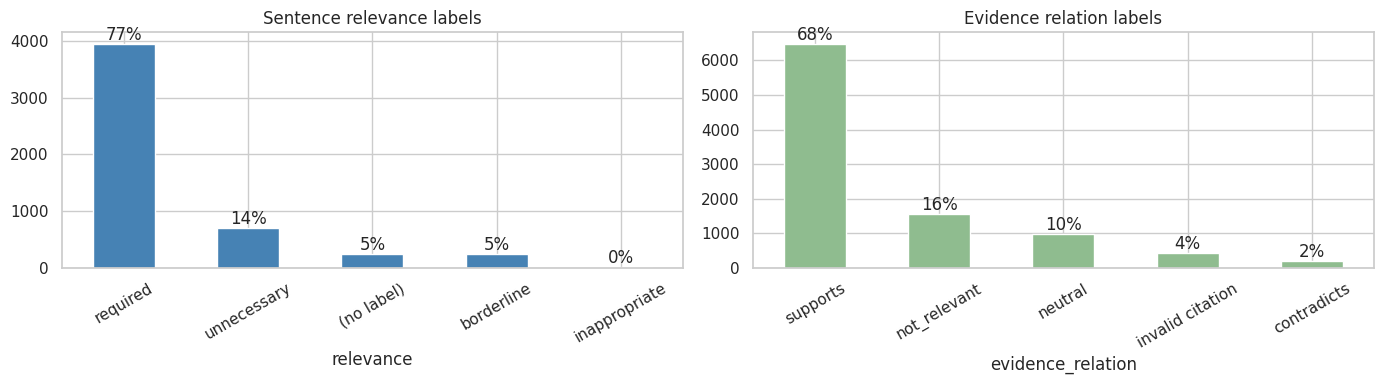

                  n   pct
relevance                
required       3958  76.7
unnecessary     698  13.5
(no label)      244   4.7
borderline      243   4.7
inappropriate    19   0.4

                      n   pct
evidence_relation            
supports           6490  67.5
not_relevant       1551  16.1
neutral             972  10.1
invalid citation    409   4.3
contradicts         189   2.0


In [ ]:
def label_bar(series, ax, title, color):
    vc = series.fillna("(no label)").value_counts()
    if vc.empty:
        ax.set_title(f"{title} — NO DATA, check accessors")
        return vc
    vc.plot(kind="bar", ax=ax, color=color)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(vc):
        ax.text(i, v, f"{v / vc.sum() * 100:.0f}%", ha="center", va="bottom")
    return vc


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
rel = label_bar(uniq_sents["relevance"], axes[0], "Sentence relevance labels", "steelblue")
ev = label_bar(sentences.loc[sentences["pmid"].notna(), "evidence_relation"],
               axes[1], "Evidence relation labels", "darkseagreen")
plt.tight_layout()
plt.show()

print(rel.to_frame("n").assign(pct=lambda d: (d["n"] / d["n"].sum() * 100).round(1)))
print()
print(ev.to_frame("n").assign(pct=lambda d: (d["n"] / d["n"].sum() * 100).round(1)))

### 5a-ii. Unlabeled sentences

Some sentences have no relevance label at all. Check whether those line up with answers
where `is_answer_accurate` is `no`. If they do, that is a real finding: the graders
skipped sentence-level work on answers they had already rejected wholesale, which means
your Verifier calibration set is implicitly conditioned on the answer being acceptable.
Say so in the report and exclude them from kappa rather than treating them as a class.

In [ ]:
crosstab = pd.crosstab(uniq_sents["answer_acceptable"].fillna("(none)"),
                       uniq_sents["relevance"].isna(),
                       rownames=["is_answer_accurate"], colnames=["relevance is null"])
print(crosstab)

n_missing = uniq_sents["relevance"].isna().sum()
print(f"\n{n_missing} of {len(uniq_sents)} sentences ({n_missing/len(uniq_sents)*100:.1f}%) have no relevance label")

labeled = uniq_sents.dropna(subset=["relevance"])
print(f"{len(labeled)} labeled sentences -> this is the real Verifier calibration pool")

relevance is null   False  True 
is_answer_accurate              
no                      0    244
yes                  4918      0

244 of 5162 sentences (4.7%) have no relevance label
4918 labeled sentences -> this is the real Verifier calibration pool


### 5b. Class imbalance — flag this to the team

This is the finding most likely to save the Verifier owner a wasted week. Both label axes
are dominated by the positive class. A Verifier that always predicts "required" and
"supports" will post high raw accuracy and a near-zero kappa.

Concretely: report the majority-class baseline accuracy alongside every Verifier number,
and make kappa the headline metric, not agreement percentage.

In [ ]:
def majority_baseline(series):
    s = series.dropna()
    if s.empty:
        return None
    return s.value_counts(normalize=True).max()

def show(name, val):
    print(f"{name:42s} {val:.1%}" if val is not None else f"{name:42s} NO DATA")

show("Majority-class baseline, relevance:", majority_baseline(uniq_sents["relevance"]))
show("Majority-class baseline, evidence relation:", majority_baseline(sentences["evidence_relation"]))
print("\nOur success criterion is >=80% Verifier-human agreement.")
print("Compare those baselines against 80% before anyone celebrates.")

Majority-class baseline, relevance:        80.5%
Majority-class baseline, evidence relation: 67.5%

Our success criterion is >=80% Verifier-human agreement.
Compare those baselines against 80% before anyone celebrates.


### 5c. The good-to-bad spread across M1–M30

The 30 methods have real quality variation. M17 had the best answer precision at 90.23,
M4 the lowest redundancy at 4.04%, and 19 of 30 methods produced zero harmful sentences.
That spread is what lets us test whether our Verifier separates faithful from unfaithful
answers, rather than just agreeing with itself.

**Deliverable:** pick a high, a middle, and a low method as a Verifier smoke test set.

In [ ]:
by_method = (
    uniq_sents
    .assign(is_required=lambda d: d["relevance"].eq("required"),
            is_inappropriate=lambda d: d["relevance"].eq("inappropriate"),
            is_unnecessary=lambda d: d["relevance"].eq("unnecessary"))
    .groupby("method_id")
    .agg(n_sentences=("sentence", "size"),
         precision=("is_required", "mean"),
         redundancy=("is_unnecessary", "mean"),
         harmfulness=("is_inappropriate", "mean"))
    .sort_values("precision", ascending=False)
)

support = (
    sentences.loc[sentences["pmid"].notna()]
    .assign(is_support=lambda d: d["evidence_relation"].eq("supports"))
    .groupby("method_id")["is_support"].mean()
    .rename("citation_support_rate")
)

by_method = by_method.join(support)
by_method.round(3)

,n_sentences,precision,redundancy,harmfulness,citation_support_rate
method_id,,,,,
M17,162,0.889,0.080,0.006,0.545
M29,147,0.884,0.048,0.000,0.687
M1,143,0.867,0.063,0.000,0.736
M12,131,0.855,0.076,0.000,0.707
M21,154,0.838,0.052,0.006,0.630
M2,223,0.834,0.130,0.000,0.704
M11,149,0.832,0.101,0.007,0.778
M20,148,0.831,0.068,0.000,0.731
M10,222,0.820,0.140,0.005,0.630


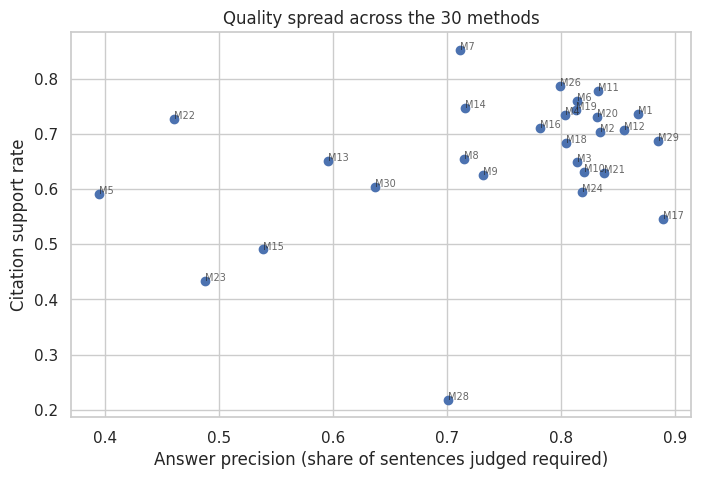

Suggested Verifier smoke-test methods (low / mid / high):
M5 | M4 | M17


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(by_method["precision"], by_method["citation_support_rate"])
for mid, r in by_method.iterrows():
    ax.annotate(mid, (r["precision"], r["citation_support_rate"]), fontsize=7, alpha=0.7)
ax.set_xlabel("Answer precision (share of sentences judged required)")
ax.set_ylabel("Citation support rate")
ax.set_title("Quality spread across the 30 methods")
plt.show()

ranked = by_method.dropna(subset=["precision"]).sort_values("precision")
print("Suggested Verifier smoke-test methods (low / mid / high):")
print(ranked.index[0], "|", ranked.index[len(ranked)//2], "|", ranked.index[-1])

## 6. Readability of machine answers vs. expert answers

Secondary, but cheap to compute and it feeds the Readability owner's baseline.

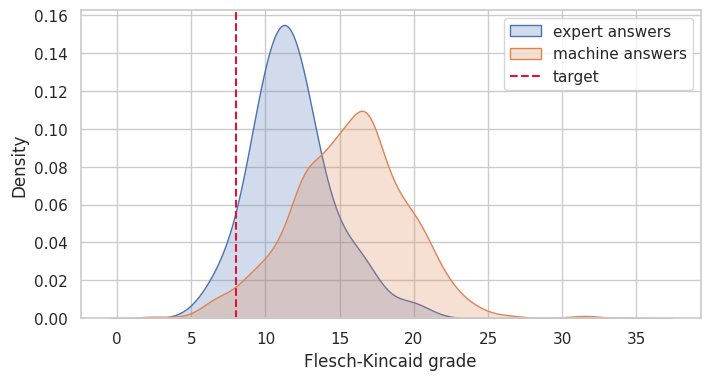

In [ ]:
sample = (uniq_sents.groupby("method_id")
          .head(40)
          .assign(fk=lambda d: d["sentence"].map(
              lambda t: textstat.flesch_kincaid_grade(t) if isinstance(t, str) and len(t.split()) > 4 else np.nan)))

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(expert["fk_grade"].dropna(), label="expert answers", ax=ax, fill=True)
sns.kdeplot(sample["fk"].dropna(), label="machine answers", ax=ax, fill=True)
ax.axvline(8, color="crimson", ls="--", label="target")
ax.set_xlabel("Flesch-Kincaid grade")
ax.legend()
plt.show()

## 7. Freeze and export

The advisor called this out explicitly: version the gold set and stop editing it. Silently
changing the eval set makes every before/after number meaningless.

Commit these CSVs plus the SHA-256 of the source JSON. If the hash changes, every number
in the report is suspect.

In [ ]:
import hashlib

digest = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print("medaesqa_v1.json sha256:", digest)

questions.to_csv("medaesqa_questions.csv", index=False)
nuggets_df.to_csv("medaesqa_nuggets.csv", index=False)
sentences.to_csv("medaesqa_sentences.csv", index=False)
by_method.to_csv("medaesqa_method_summary.csv")

with open("medaesqa_freeze.txt", "w") as f:
    f.write(f"source: medaesqa_v1.json\nsha256: {digest}\n")
    f.write(f"n_questions: {len(questions)}\n")
    f.write(f"n_nuggets: {len(nuggets_df)}\n")
    f.write(f"n_sentence_citation_rows: {len(sentences)}\n")

print("wrote 4 CSVs + freeze manifest")

medaesqa_v1.json sha256: a062742c1678b4379121ad030a06bda574afd376f331df41575938dd9849c383
wrote 4 CSVs + freeze manifest


## 8. Findings summary

Fill this in after running. Keep it to the things another fellow needs to act on.

| # | Finding | Who needs it | Action |
|---|---------|--------------|--------|
| 1 | Expert answers sit at grade X, well above our grade-8 target | everyone | motivating stat for the report |
| 2 | Relevance labels are ~77% `required`; majority baseline is X% | Verifier | report kappa, not accuracy |
| 3 | Evidence relations are ~68% `supports` | Verifier | same |
| 4 | Nuggets use N distinct predicates; X% break the two-arg pattern | Extractor | schema design |
| 5 | CUI coverage is X% | Extractor | whether a UMLS lookup tool is worth it |
| 6 | Method quality spans X to Y precision | Verifier | smoke-test set |
| 7 | Question mix skews toward [body systems / specialties] | everyone | named limitation in December report |

**Open questions for the advisor:**
- (add yours here)

**Citation:** Gupta, D., Bartels, D. & Demner-Fushman, D. *A Dataset of Medical Questions
Paired with Automatically Generated Answers and Evidence-supported References.*
Scientific Data 12, 1035 (2025). CC BY 4.0.